<a href="https://colab.research.google.com/github/avishek-astra/Deep_Learning_Experiments/blob/main/Transferlearning_codechallengeVGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
#import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

#for importing data
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')


In [22]:
#use GPU if available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

Import a dataset

In [23]:
###Note:resnet is trained for images in a specific range (NOT[-1,1])
# That changes the mean/std normalization values in the transfrom
#transformations
transform=T.Compose([T.ToTensor(),#normalizes to range[0,1]
                     T.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])#further normalization
])
#import the data and simultaneously apply the transform
trainset=torchvision.datasets.STL10(root='./data',download=True,split='train',transform=transform)
testset=torchvision.datasets.STL10(root='./data',download=True,split='test',transform=transform)
#transform to dataloaders
batchsize=32
train_loader=DataLoader(trainset,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader=DataLoader(testset,batch_size=256)

In [24]:
#check out the shapes of the datasets
print('Data shapes(train/test)')
print(trainset.data.shape)
print(testset.data.shape)

#and the range of pixel intensity values
print('Data range')
print(trainset.data.min(),trainset.data.max())
#the unique categories
print('Classes')
print(trainset.classes)

Data shapes(train/test)
(5000, 3, 96, 96)
(8000, 3, 96, 96)
Data range
0 255
Classes
['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [25]:
X,y =next(iter(train_loader))

#data shapes
print('Data shapes(TRAIN/TEST)')
print(X.data.shape)

#and the range of pixel intensity values
print('Data range')
print(torch.min(X.data),torch.max(X.data))


Data shapes(TRAIN/TEST)
torch.Size([32, 3, 96, 96])
Data range
tensor(-2.1179) tensor(2.6400)


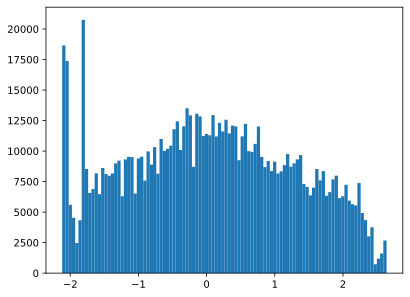

In [26]:
#histogram of the data
plt.hist(X.data.numpy().flatten(),bins=100)
plt.show()

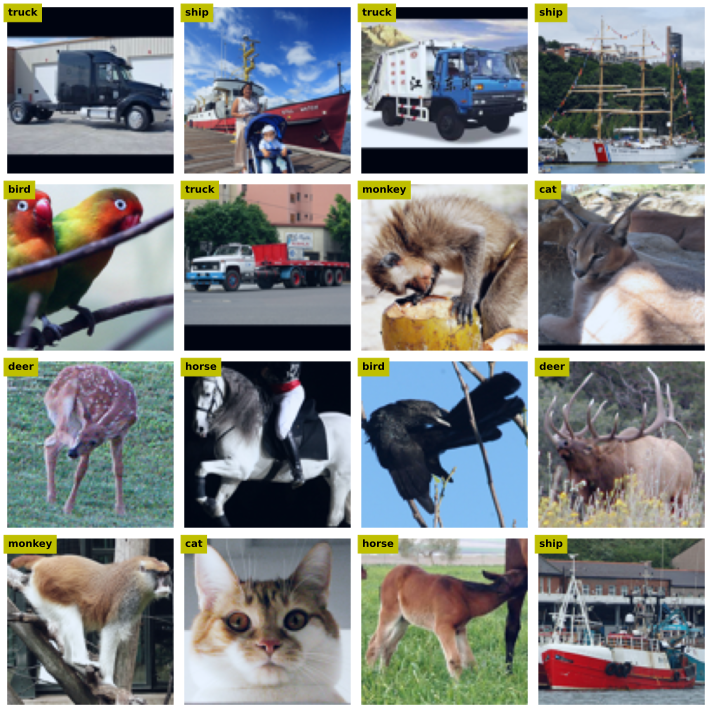

In [27]:
#inspect a few random images
fig,axs=plt.subplots(4,4,figsize=(10,10))
for (i,ax) in enumerate(axs.flatten()):
  #extract the images(need to transpose it back to 32X32X3
  pic=X.data[i].numpy().transpose((1,2,0))
  pic=pic-np.min(pic)
  pic=pic/np.max(pic)
  #and its label
  label=trainset.classes[y[i]]
  #and show
  ax.imshow(pic)
  ax.text(0,0,label,ha='left',va='top',fontweight='bold',color='k',backgroundcolor='y')
  ax.axis('off')
plt.tight_layout()
plt.show()

In [28]:
vggnet=torchvision.models.vgg16(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [29]:
#let's inspect this network
vggnet

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [30]:
from torchsummary import summary
summary(vggnet.to(device),(3,96,96))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 96, 96]           1,792
              ReLU-2           [-1, 64, 96, 96]               0
            Conv2d-3           [-1, 64, 96, 96]          36,928
              ReLU-4           [-1, 64, 96, 96]               0
         MaxPool2d-5           [-1, 64, 48, 48]               0
            Conv2d-6          [-1, 128, 48, 48]          73,856
              ReLU-7          [-1, 128, 48, 48]               0
            Conv2d-8          [-1, 128, 48, 48]         147,584
              ReLU-9          [-1, 128, 48, 48]               0
        MaxPool2d-10          [-1, 128, 24, 24]               0
           Conv2d-11          [-1, 256, 24, 24]         295,168
             ReLU-12          [-1, 256, 24, 24]               0
           Conv2d-13          [-1, 256, 24, 24]         590,080
             ReLU-14          [-1, 256,

In [31]:
##freeze all layers
for p in vggnet.parameters():
  p.requires_grad=False

In [46]:
#change the final layer
vggnet.classifier=nn.Sequential(nn.Linear(512 * 7 * 7, 10))

# Print the updated classifier to verify
print(vggnet.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=10, bias=True)
)


In [52]:
vggnet.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Train the model

In [48]:
lossfun = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(vggnet.parameters(),lr=0.001,momentum=.9)

In [49]:
numepochs = 10

# initialize losses
trainLoss = torch.zeros(numepochs)
testLoss  = torch.zeros(numepochs)
trainAcc  = torch.zeros(numepochs)
testAcc   = torch.zeros(numepochs)

# loop over epochs
for epochi in range(numepochs):

  # loop over training data batches
  vggnet.train() # switch to train mode
  batchLoss = []
  batchAcc  = []
  for X,y in train_loader:

    # push data to GPU
    X = X.to(device)
    y = y.to(device)

    # forward pass and loss
    yHat = vggnet(X)
    loss = lossfun(yHat,y)

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # loss and accuracy from this batch
    batchLoss.append(loss.item())
    batchAcc.append( torch.mean((torch.argmax(yHat,axis=1) == y).float()).item() )
  # end of batch loop...

  # and get average losses and accuracies across the batches
  trainLoss[epochi] = np.mean(batchLoss)
  trainAcc[epochi]  = 100*np.mean(batchAcc)


  #### test performance (here done in batches!)
  vggnet.eval() # switch to test mode
  batchAcc  = []
  batchLoss = []
  for X,y in test_loader:

    # push data to GPU
    X = X.to(device)
    y = y.to(device)

    # forward pass and loss
    with torch.no_grad():
      yHat = vggnet(X)
      loss = lossfun(yHat,y)

    # loss and accuracy from this batch
    batchLoss.append(loss.item())
    batchAcc.append( torch.mean((torch.argmax(yHat,axis=1) == y).float()).item() )
  # end of batch loop...

  # and get average losses and accuracies across the batches
  testLoss[epochi] = np.mean(batchLoss)
  testAcc[epochi]  = 100*np.mean(batchAcc)

  # print out a status update
  print(f'Finished epoch {epochi+1}/{numepochs}. Test accuracy = {testAcc[epochi]:.2f}%')

Finished epoch 1/10. Test accuracy = 87.67%
Finished epoch 2/10. Test accuracy = 88.90%
Finished epoch 3/10. Test accuracy = 88.59%
Finished epoch 4/10. Test accuracy = 91.09%
Finished epoch 5/10. Test accuracy = 90.80%
Finished epoch 6/10. Test accuracy = 91.63%
Finished epoch 7/10. Test accuracy = 91.39%
Finished epoch 8/10. Test accuracy = 91.27%
Finished epoch 9/10. Test accuracy = 91.27%
Finished epoch 10/10. Test accuracy = 91.41%


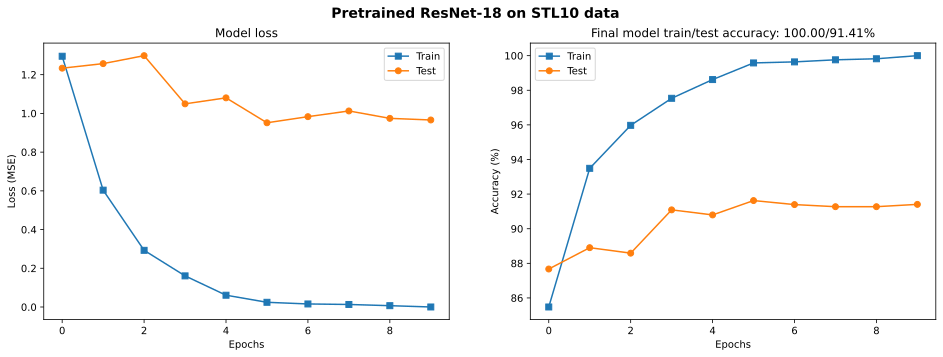

In [50]:

fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(trainLoss,'s-',label='Train')
ax[0].plot(testLoss,'o-',label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (MSE)')
ax[0].set_title('Model loss')
ax[0].legend()

ax[1].plot(trainAcc,'s-',label='Train')
ax[1].plot(testAcc,'o-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model train/test accuracy: {trainAcc[-1]:.2f}/{testAcc[-1]:.2f}%')
ax[1].legend()

plt.suptitle('Pretrained ResNet-18 on STL10 data',fontweight='bold',fontsize=14)
plt.show()


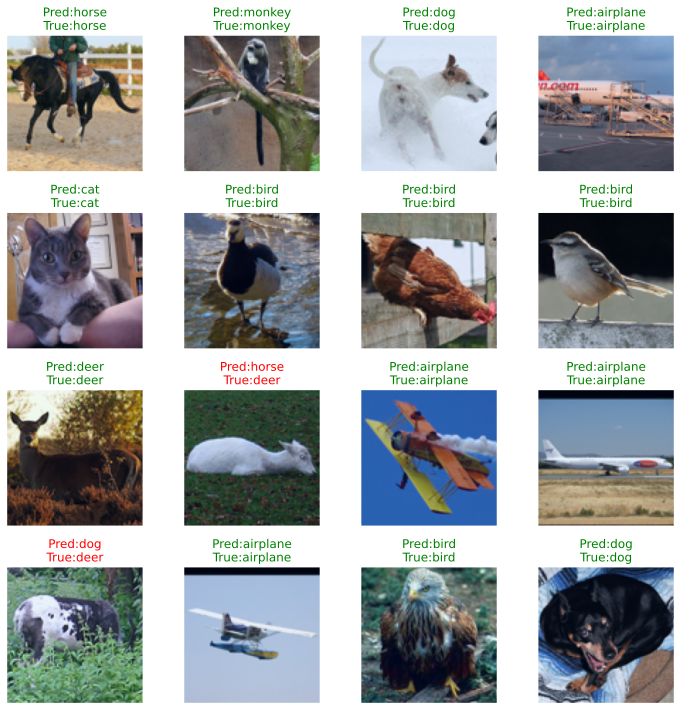

In [51]:
#inspect a few random images
X,y =next(iter(test_loader))
X=X.to(device)
y=y.to(device)
vggnet.eval()
predictions=torch.argmax(vggnet(X),axis=1)
fig,axs=plt.subplots(4,4,figsize=(10,10))
for (i,ax) in enumerate(axs.flatten()):
  #extract the images(need to transpose it back to 32X32X3
  pic=X.data[i].cpu().numpy().transpose((1,2,0))
  pic=pic-np.min(pic)
  pic=pic/np.max(pic)
  #and its label
  label=trainset.classes[y[i]]
  #and show
  ax.imshow(pic)
  #label and true classes
  label_pred=trainset.classes[predictions[i]]
  truec=trainset.classes[y[i]]
  title=f'Pred:{label_pred}\nTrue:{truec}'
  #set the title with color coded accuracy
  titlecolor='g' if label_pred==truec else 'r'
  ax.set_title(title,color=titlecolor)
  ax.axis('off')
  #and show
plt.tight_layout()
plt.show()